# **Topics and trends discovery module**

 - 0. Introduction
 - 1. Gathering data & dataset analysis
   - a. An initial look at the data
   - b. Parse data
   - c. Save Dataset to Pandas Dataframe
- 2. Data Science  
  - a. The difference in Computer Science research topics per decade - Clustering
  - b. Smart topic recommendation using emmbeding

## 0. Introduction

This project is focused on analizing the biggest available dataset about Computer Science Papers. My main goal is to extract the most interesting information and use best fit of AI/ML models for this problem.

In this first module called "Topics and trends discovery" I'm going to anlyze reseacrh papers topics trends during three decades - 2004, 2014 and 2024.

`You will find various notes interspersed throughout the text, detailing my thought process and the challenges I encountered during the project` - all conflicts, troubleshooting, reflections, some knowledge from my experience and other. I encourage you to read them. I also hope my comments are clear and understandable - sorry for any typos but I've probably wrote this at night! :)

In [1]:
# Frameworks
import os
os.chdir('..')

from lxml import etree
import numpy as np
import pandas as pd
from src.data_analysis_helper import DataAnalysisHelper
from sentence_transformers import SentenceTransformer 
from umap import UMAP
import matplotlib.pyplot as plt 
from hdbscan import HDBSCAN 
from bertopic import BERTopic
from transformers import pipeline 
from bertopic.representation import TextGeneration 
import seaborn as sns

c:\projekty\DBLP-analysis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Dataset analysis

One of most crucial steps in Data Science is to fully understand the concept. Therefore, my first priority will be to analyze the dataset structure

For xml file read I've decided to use lxml library, because it's more time efficient than a standard Python library for *.xml.

### An initial look at the data
Based on the dblp.dtd, the available XML tags are as follows:


main:
- `article` - artykuł naukowy opublikowany w czasopiśmie
- `inproceedings` - artykuł w materiałach konferencyjnych
- `proceedings` - całe materiały konferencyjne (zbiór artykułów)
- `book` - książka (monografia)
- `incollection` - rozdział w książce lub pracy zbiorowej
- `phdthesis` - rozprawa doktorska
- `mastersthesis` - praca magisterska
- `www` - zasób internetowy (np. strona WWW)
- `person` - informacja o osobie (np. autorze)
- `data` - zbiór danych lub dataset

Parameter Entity:
- `author` - autor publikacji
- `editor` - redaktor (np. książki lub materiałów konferencyjnych)
- `title` - tytuł publikacji
- `booktitle` - tytuł książki lub konferencji, w której opublikowano pracę
- `pages` - zakres stron
- `year` - rok publikacji
- `address` - miejsce wydania (np. miasto)
- `journal` - nazwa czasopisma
- `volume` - numer tomu
- `number` - numer wydania w ramach tomu
- `month` - miesiąc publikacji
- `url` - link do publikacji
- `ee` - link do wersji elektronicznej (electronic edition)
- `cdrom` - lokalizacja wersji na nośniku CD-ROM
- `cite` - odwołanie do innej publikacji
- `publisher` - wydawnictwo
- `note` - dodatkowe informacje
- `crossref` - odwołanie do innego wpisu (np. konferencji)
- `isbn` - numer ISBN książki
- `series` - seria wydawnicza
- `school` - uczelnia (dla prac dyplomowych)
- `chapter` - numer rozdziału
- `publnr` - numer publikacji (np. raportu technicznego)
- `stream` - strumień lub kategoria publikacji
- `rel` - relacja z innymi wpisami

Stats of dataframe:

![df_stats](png\dataframe_statistics.png)

![stats_2](png\df_stats_2.png)

I wanted to extract as much data as possible, therefore I wrote parse_publications() and _is_record_complete_enough() functions in my helper class. unfortunately, even if I seted threshold to 0.5 Series output was empty. That's why I've decided to set my threshold to False and only take "title", "author" and type of publication.

### Parse data
from *.xml file

My first idea was to pick 100 papaers from every month from every year. By this method, our data would be heterogeneous and representative. However, results in tests showed that there're not enough labaled 'month' tags for later unsupervised clustering implementation. Because of that, I needed to pick the total value, without breakdown by months.

In [2]:
# Important sets, lists and path
all_top_tags = {"article", "inproceedings", "proceedings", "book", 
                        "incollection", "phdthesis", "mastersthesis", "www", "person", "data"}

year_range = ["2004", "2014", "2024"]

xml_path = r"C:\Users\wikto\OneDrive\Dokumenty\all-datasets\dblp-dataset\dblp.xml"

# Initialize the helper class and call the method within to
# Extract publication data filtered by the specified year range
helper_class = DataAnalysisHelper(xml_path, all_top_tags)
publications = helper_class.parse_publications(year_range, target_limit=5000)


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\wikto\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\wikto\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\wikto\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Limit reached for 2024....
Checked 100000 records...
Limit reached for 2014....
Checked 200000 records...
Limit reached for 2004....
Limit reached for every year. Ending....


### Save Dataset to Pandas Dataframe

In [3]:
flatted_data = []
for year, records in publications.items():
    for record in records:
        flatted_data.append({
            "Year": year,
            "Type": record["type"],      
            "Author": record["author"],  
            "Title": record["title"],    
            "Journal": record["journal"],
            "Booktitle": record["booktitle"],
            "Address": record["address"],
            "Month": record["month"]
        })

df = pd.DataFrame(flatted_data)

In [4]:
# Look on main dataset
df

,Year,Type,Author,Title,Journal,Booktitle,Address,Month
0,2004,book,Jeremy J. Ramsden,Bioinformatics: An Introduction,None,None,None,None
1,2004,book,None,Artificial Intelligence Methods And Tools For ...,None,None,None,None
2,2004,book,None,The Rise of Modern Logic: From Leibniz to Frege,None,None,None,None
3,2004,book,None,"Greek, Indian and Arabic Logic",None,None,None,None
4,2004,book,Klaus Schneider 0001,Verification of Reactive Systems - Formal Meth...,None,None,None,None
...,...,...,...,...,...,...,...,...
14995,2024,inproceedings,"Susan Zhao, Katharine Walters, José A. Montes-...","Design and Validation of a Modular, Backdrivab...",None,BioRob,None,None
14996,2024,inproceedings,"Huibert A. J. van Riessen, Yasemin Vardar",Relocating Thermal Stimuli to the Proximal Pha...,None,BioRob,None,None
14997,2024,inproceedings,"J. Boehm, J. Rominger, L. Buatier de Mongeot, ...",Simulation of an Online Estimation Algorithm f...,None,BioRob,None,None
14998,2024,inproceedings,"L. Alizadehsaravi, S. Drauksas, J. K. Moore, R...",Enhancing Motor Learning in Cycling Tasks: The...,None,BioRob,None,None


## 2. Data Science

### The difference in Computer Science research topics per decadeusing unsupervised methods
In this section, I will analyze the evolution of research topics across three decades. Since the dataset is unlabeled, classic supervised learning is not an option unless I were to label the samples manually. For this, I'm going to use NLP and clustering techniques.

1. `Preprocess` - of course, computer is a binary machine that doesn't understand a concept of words as letters. That's why it's important to change words to vector float representation. For this, data needs to be clean - with no upperletters, stopwords or other type of noise.
2. `Embedding` - as I've said, we need numeric representetion of words. Embedding is a method that changes words to numbers, and represents them in high dimension. For example, words like "cat" and "dog" are going to be closer to each other than "car".
3. `Reduce the dimensionality` - we can not see in more than third dimension, that's why in unsupervised learning we use methods like **PCA, UMAP or t-SNE** to reduce the dimension. This is particularly important for visualizing clusters of semantically similar words.
4. `Cluster` -
5. `Plot` - 

Preprocess data

In [5]:
# Preprocess data for NLP ready usage
prepared_titles = helper_class.preprocess_for_nlp(df, "Title")
prepared_titles



0                           [bioinformatics, introduction]
1        [artificial, intelligence, methods, tools, sys...
2                    [rise, modern, logic, leibniz, frege]
3                           [greek, indian, arabic, logic]
4        [verification, reactive, systems, formal, meth...
                               ...                        
14995    [design, validation, modular, backdrivable, an...
14996    [relocating, thermal, stimuli, proximal, phala...
14997    [simulation, online, estimation, algorithm, ti...
14998    [enhancing, motor, learning, cycling, tasks, r...
14999    [identification, significant, tactile, sensing...
Name: Title, Length: 15000, dtype: object

Embedding

In [6]:
# Embedding

# ! ! For now I use gte model - which has it's own tokenize methold build within. ! !
# ! ! That's why I don't use preprocessed titles. ! !
only_titles = df['Title']
only_titles = only_titles.str.lower()

'''Code below is commented out to prevent downloading'''
# !! I use multiligual model - there're many languages in dataset !!

texts_to_encode_for_e5 = ("passage: " + only_titles).tolist() # Perifix is necessary for e5 models

embedding_model = SentenceTransformer('intfloat/multilingual-e5-small') 
embeddings = embedding_model.encode(texts_to_encode_for_e5, show_progress_bar=True, normalize_embeddings=True)


Batches: 100%|██████████| 469/469 [01:44<00:00,  4.49it/s]


In [7]:

# !! Save embeddings !!
np.save('C:\projekty\DBLP-analysis\data\dblp_embeddings_bigger_data_sample.npy', embeddings)


In [8]:

# Load embeddings - for now, easy numpy (bc I want plot some correlations)
# For RAG and smart searchers i would to use vector databases like ChromaDB (which I use in my second module)

embeddings = np.load(r"C:\projekty\DBLP-analysis\data\dblp_embeddings_bigger_data_sample.npy")



Reduce dimensionality

In [9]:
# Reduce dimensionality for visualization and clustering
# I’ll use UMAP as it tends to handle nonlinear relationships better

umap_reduce = UMAP(n_components=2, min_dist=0.0, metric='cosine', random_state=123)
reduced_embeddings = umap_reduce.fit_transform(embeddings)

# Important! UMAP and every dimensionality reducing algorithm can cause information loss.

Cluster

In [10]:
# Clustering using density-based algorithms
# those algorithms calculate the number of clusters freely and do not force all points into a cluster.
# We’ll use HDBSCAN for our case.
n_min_clust = 240

hdbscan_model = HDBSCAN(min_cluster_size=n_min_clust, metric="euclidean", cluster_selection_method="eom",
                        prediction_data=True).fit(reduced_embeddings)
clusters = hdbscan_model.labels_



Plot data

(np.float64(-3.9167697191238404),
 np.float64(6.493002152442932),
 np.float64(5.540545248985291),
 np.float64(13.697447514533996))

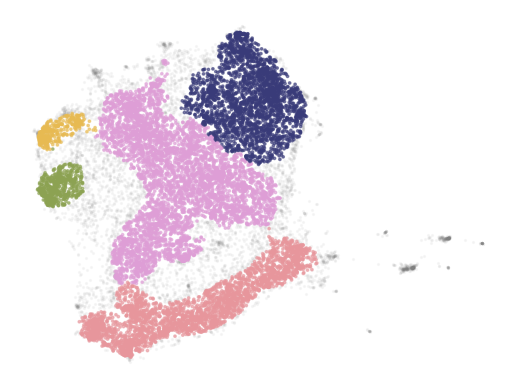

In [11]:
# Plot data

df_clusters = pd.DataFrame(reduced_embeddings, columns=["x1", "x2"])
df_clusters["title"] = only_titles
df_clusters["cluster"] = [str(c) for c in clusters] 

# Outliers and non outliers
to_plot = df_clusters.loc[df_clusters.cluster != "-1", :] 
outliers = df_clusters.loc[df_clusters.cluster == "-1", :]

plt.scatter(outliers.x1, outliers.x2, alpha=0.05, s=2, c="grey") 
plt.scatter(to_plot.x1, to_plot.x2, c=to_plot.cluster.astype(int), alpha=0.6, s=3, cmap="tab20b" ) 
plt.axis("off")

Statistics - charts, analyze popularity

In [12]:
# Statistics
df_year_titles = df[['Year', 'Title']]
df_with_clusters = df_year_titles.join(df_clusters)

df_with_clusters
df_without_noise = df_with_clusters[df_with_clusters['cluster'] != "-1"]
df_without_noise['cluster'] = df_without_noise['cluster'].astype("Int64")

df_without_noise_n = df_without_noise

In [13]:
unique, counts = np.unique(clusters, return_counts=True)
cluster_stats = dict(zip(unique, counts))

print("Claster statistics:")
print(cluster_stats)

# Clusters with class "-1" are classified as noise
print(sorted(cluster_stats.values()))

Claster statistics:
{np.int64(-1): np.int64(4165), np.int64(0): np.int64(2568), np.int64(1): np.int64(524), np.int64(2): np.int64(329), np.int64(3): np.int64(2836), np.int64(4): np.int64(4578)}
[np.int64(329), np.int64(524), np.int64(2568), np.int64(2836), np.int64(4165), np.int64(4578)]


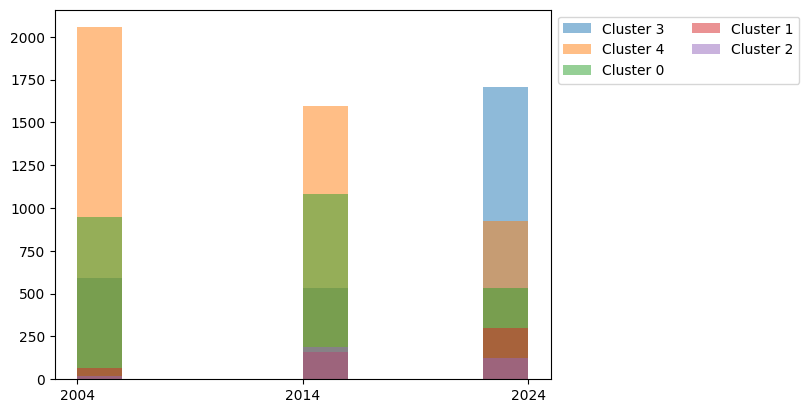

In [14]:
for cluster_id in df_without_noise["cluster"].unique():
    subset = df_without_noise[df_without_noise["cluster"] == cluster_id]
    plt.hist(subset["Year"], alpha=0.5, label=f"Cluster {cluster_id}")

plt.legend(loc='upper left', bbox_to_anchor=(1, 1), ncol=2)
plt.show()

**Simply identifying clusters by number is insufficient for a meaningful time-trend analysis. To address this, I will implement a neural network to classify and label these clusters**

Check what titles are in clusters

In [15]:
pd.set_option('display.max_colwidth', None)
print(f"Example titles for cluster 1:\n {df_without_noise['title'][df_without_noise['cluster'] == 1].iloc[:3]}")


Example titles for cluster 1:
 34     cybertherapy - internet and virtual reality as assessment and rehabilitation tools for clinical psychology and neuroscience
786                                             gaze-contingent display using texture mapping and opengl: system and applications.
794                                     a free-head, simple calibration, gaze tracking system that enables gaze-based interaction.
Name: title, dtype: object


In [16]:

print(f"Example titles for cluster 2:\n {df_without_noise['title'][df_without_noise['cluster'] == 2].iloc[:3]}")


Example titles for cluster 2:
 506                       backcalculation of airport flexible pavement non-linear moduli using artificial neural networks.
635                                                 intelligent control of closed-loop sedation in simulated icu patients.
1254    experimental implementation of robust and intelligent controllers in trajectory control of industrial scara robot.
Name: title, dtype: object


In [17]:

print(f"Example titles for cluster 4:\n {df_without_noise['title'][df_without_noise['cluster'] == 4].iloc[:3]}")

Example titles for cluster 4:
 15    numerical solution of elliptic differential equations by reduction to the interface.
17                                    multiresolution methods in scattered data modelling.
19                                                                     multimedia systems.
Name: title, dtype: object


*Topic modeling approach is more probabilistic*. For example, in this approach we can classify some papper as 80% about network protocols, and other 20% about Machine Learning (for example, there was used ML algorithm for networks). It gives us more freedom - and more immportly, we can see some trend in passing years.

We use our prevoius defined pipeline - embedding, dimensionality reuction etc...
However, now we use BERTopic which automatically finds the main topics in large collections of texts. 
Once the clusters are formed, it uses a Bag-of-Words technique to treat each cluster as a single large "document". It sums each informantion in cluster into one and checks frequency of words.

In [18]:
import nltk
from nltk.corpus import stopwords

stop_words_set = set(stopwords.words('english'))

#only_titles_new = helper_class.remove_stop_words(only_titles)

topic_model = (BERTopic(embedding_model=embedding_model, 
                        umap_model=umap_reduce,
                        hdbscan_model=hdbscan_model,
                        verbose=True,
                        calculate_probabilities=True)
               .fit(only_titles, embeddings))

2026-04-07 12:28:54,384 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-07 12:29:07,286 - BERTopic - Dimensionality - Completed ✓
2026-04-07 12:29:07,288 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-07 12:29:09,562 - BERTopic - Cluster - Completed ✓
2026-04-07 12:29:09,571 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-07 12:29:09,785 - BERTopic - Representation - Completed ✓


In [19]:
from sklearn.feature_extraction.text import CountVectorizer

# Delete stopwords like "and", "or"...
nltk.download('stopwords')
polish_stopwords = stopwords.words('english')

vectorizer_model = CountVectorizer(stop_words=polish_stopwords)
topic_model.update_topics(only_titles, vectorizer_model=vectorizer_model)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\wikto\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [20]:
pd.reset_option('display.max_colwidth')
bert_topic_df = topic_model.get_topic_info()

# First 5 classes by BERTopic
bert_topic_df.head()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,4165,-1_de_based_using_learning,"[de, based, using, learning, analysis, 3d, dat...",[technological platform to aid the exchange of...
1,0,4578,0_based_using_learning_image,"[based, using, learning, image, data, analysis...",[on the segmentation and classification of wat...
2,1,2836,1_language_models_large_llms,"[language, models, large, llms, knowledge, dat...",[exploring knowledge from knowledge graphs and...
3,2,2568,2_networks_based_systems_network,"[networks, based, systems, network, wireless, ...",[clustering based routing strategies for energ...
4,3,524,3_reality_virtual_augmented_vr,"[reality, virtual, augmented, vr, mixed, gaze,...",[interactive tools for virtual x-ray vision in...


In [21]:
# Plot
fig = topic_model.visualize_documents(only_titles, reduced_embeddings=reduced_embeddings, width=1200, hide_annotations=True ) 
fig.update_layout(font=dict(size=22))

Now we have base for label by LLM.

In [22]:
from bertopic.representation import MaximalMarginalRelevance 

# Update our topic representations to MaximalMarginalRelevance 
representation_model = MaximalMarginalRelevance(diversity=0.2) 
topic_model.update_topics(only_titles, representation_model=representation_model, vectorizer_model=vectorizer_model)

topic_model.get_topic_info().head()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,4165,-1_learning_analysis_3d_detection,"[learning, analysis, 3d, detection, models, mu...",[technological platform to aid the exchange of...
1,0,4578,0_learning_analysis_detection_classification,"[learning, analysis, detection, classification...",[on the segmentation and classification of wat...
2,1,2836,1_language_llms_llm_reasoning,"[language, llms, llm, reasoning, learning, mul...",[exploring knowledge from knowledge graphs and...
3,2,2568,2_networks_wireless_performance_system,"[networks, wireless, performance, system, anal...",[clustering based routing strategies for energ...
4,3,524,3_reality_virtual_augmented_vr,"[reality, virtual, augmented, vr, exploring, i...",[interactive tools for virtual x-ray vision in...


In [23]:
fig = topic_model.visualize_documents(only_titles, reduced_embeddings=reduced_embeddings, width=1200, hide_annotations=True ) 
fig.update_layout(font=dict(size=22))

fig.save(f"C:\projekty\DBLP-analysis\graphs\graph_n={n_min_clust}")

AttributeError: 'Figure' object has no attribute 'save'

In [ ]:
only_titles_list = only_titles.astype(str).tolist()

In [ ]:
prompt = "Titles: [DOCUMENTS]\nKeywords: [KEYWORDS]\nTopic Label:"


generator = pipeline("text2text-generation", model='google/flan-t5-small')

representation_model = TextGeneration(generator, prompt=prompt, doc_length=50, tokenizer="whitespace") 
topic_model.update_topics(only_titles_list, representation_model=representation_model)

100%|██████████| 6/6 [00:01<00:00,  3.15it/s]


In [ ]:
# Names of clusters by LLM 
labeled_clusters_df = topic_model.get_topic_info()

# only names named by t5-small model
topic_names = labeled_clusters_df['Name']

#without noise
topic_names = topic_names[1:]

labeled_clusters_df = labeled_clusters_df[labeled_clusters_df['Topic'] != -1]
labeled_clusters_df.head()

,Topic,Count,Name,Representation,Representative_Docs
1,0,4578,0_Image processing and modeling approaches to ...,[Image processing and modeling approaches to i...,[on the segmentation and classification of wat...
2,1,2836,1_Learning via text-to-image retrieval with la...,[Learning via text-to-image retrieval with lar...,[exploring knowledge from knowledge graphs and...
3,2,2568,2_Networks and networks for the smart grid___,"[Networks and networks for the smart grid, , ,...",[clustering based routing strategies for energ...
4,3,524,3_augmented reality - augmented reality___,"[augmented reality - augmented reality, , , , ...",[interactive tools for virtual x-ray vision in...
5,4,329,4_Learning and movement of the gait in a robot...,[Learning and movement of the gait in a roboti...,[the use of gyroscope feedback in the control ...


In [ ]:
fig = topic_model.visualize_documents(only_titles, reduced_embeddings=reduced_embeddings, width=1200, hide_annotations=True ) 
fig.update_layout(font=dict(size=10))
fig.save(f"C:\projekty\DBLP-analysis\graphs\graph_n={n_min_clust}")

###  Output Analysis

In [ ]:
# Pobierz info o tematach bezpośrednio z modelu
topic_info = topic_model.get_topic_info()[['Topic', 'Name']]

# Wyczyszczenie nazwy (opcjonalnie, domyślnie jest np. "0_kawa_herbata")
topic_info['Name'] = topic_info['Name'].str.split('_', n=1).str[1]

# Merge bezpośrednio z tabelą wyników
df_without_noise = df_without_noise.merge(topic_info, how='left', left_on='cluster', right_on='Topic')

Histogram of popularity

In [26]:

plt.figure(figsize=(14, 6))

for cluster_id in df_without_noise["cluster"].unique():
    subset = df_without_noise[df_without_noise["cluster"] == cluster_id]
    
    cluster_title = subset["Name"].iloc[0] 

    plt.hist(subset["Year"], alpha=0.6, label=str(cluster_title))


plt.grid(True, linestyle='--', alpha=0.7) 
plt.legend(loc='lower right', bbox_to_anchor=(1, 1), ncol=2, fontsize='small')
plt.tight_layout()
#plt.savefig(f"C:\projekty\DBLP-analysis\graphs\graph_n={n_min_clust}")
plt.show()


KeyError: 'Name'

<Figure size 1400x600 with 0 Axes>

Clasters Heatmap

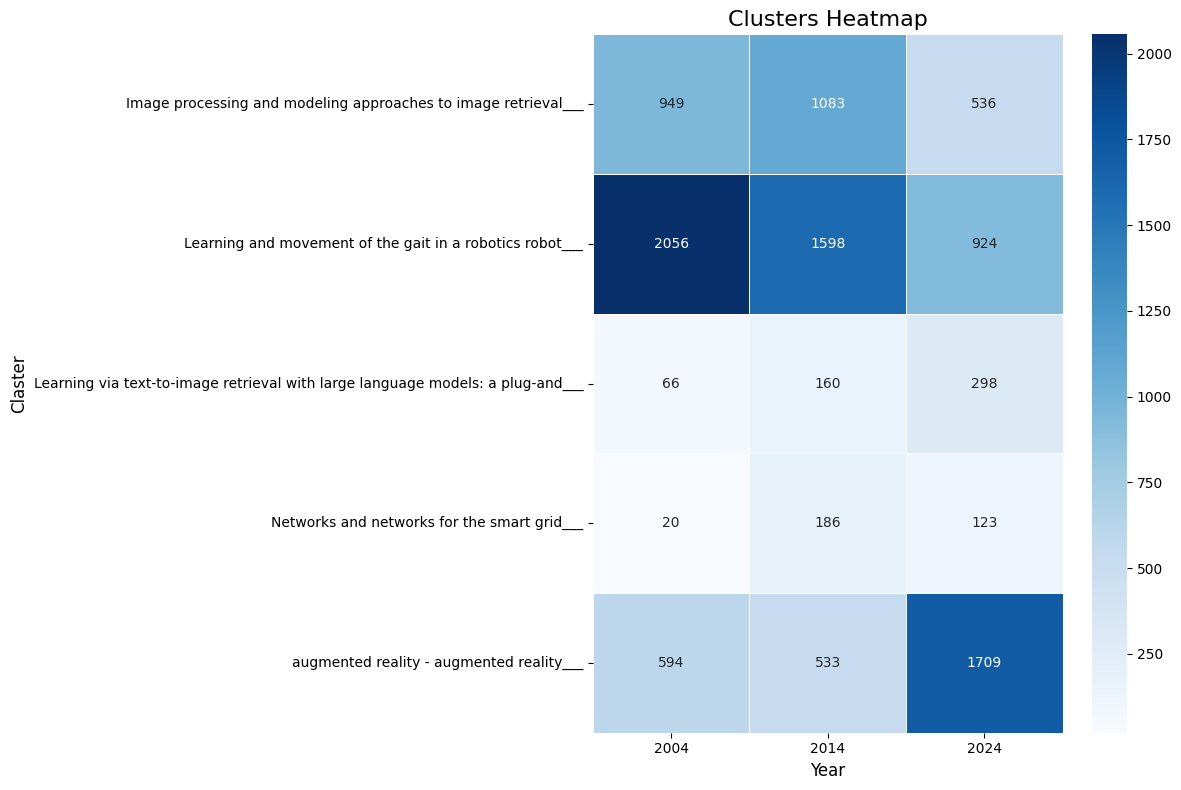

In [ ]:
df_counts = df_without_noise.groupby(['Year', 'Name']).size().reset_index(name='count')

pivot_df = df_counts.pivot(index='Name', columns='Year', values='count').fillna(0)

plt.figure(figsize=(12, 8)) 
sns.heatmap(pivot_df, cmap='Blues', annot=True, fmt='g', linewidths=.5)

plt.title('Clusters Heatmap', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Claster', fontsize=12)
plt.tight_layout()
plt.savefig(f"C:\projekty\DBLP-analysis\graphs\graph_n={n_min_clust}")
plt.show()

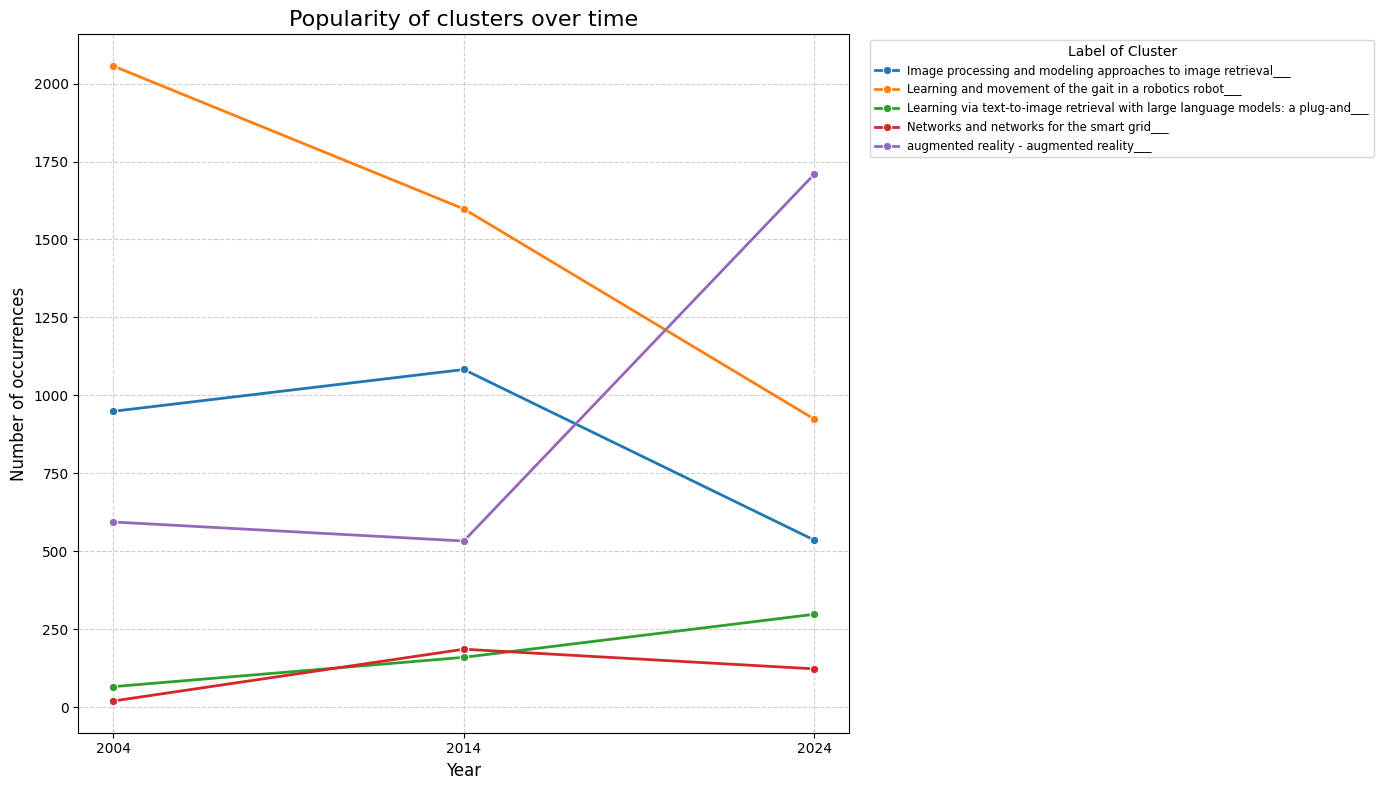

In [ ]:

df_counts = df_without_noise.groupby(['Year', 'Name']).size().reset_index(name='count')

plt.figure(figsize=(14, 8))
sns.lineplot(data=df_counts, x='Year', y='count', hue='Name', marker='o', linewidth=2)

plt.title('Popularity of clusters over time', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of occurrences', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize='small', title='Label of Cluster')
plt.tight_layout()
plt.savefig(f"C:\projekty\DBLP-analysis\graphs\graph_n={n_min_clust}")
plt.show()

## Conclusion

This module focuses on investigating shifting paradigms in Computer Science by comparing data from 2004, 2014, and 2024. I also experimented with lightweight models (SLMs) to assess their capability in identifying and categorizing these trends compared to larger architectures.

The clustering model played a pivotal role in the analysis, as the minimum cluster size significantly influenced the final results. It was necessary to conduct several experiments to determine the optimal threshold where clusters remained cohesive and conceptually meaningful

The analysis showed significant insights, particularly regarding the shifting landscape of Computer Science. The data visualizations (available for various minimum cluster sizes in the Notion report) reveal a dramatic surge in LLM popularity between 2014 and 2024, reflecting what could be described as an "AI Bubble" or a period of peak inflated expectations. In contrast, Wireless Networks maintained a steady presence from 2004 to 2014, followed by a noticeable decline in 2024 as research priorities shifted.

The choice of models was primarily dictated by hardware constraints and time limitations. While I conclude that utilizing more powerful models- such as those available via proprietary APIs from leading AI labs would yield higher precision, I intentionally opted for open-source models from Hugging Face. This allowed me to demonstrate the underlying process and experiment with local execution. However, for the second module focusing on the RAG pipeline, I leveraged API-based models to ensure optimal document retrieval and recommendation quality.

I observed a significant limitation in the neural network used for automated labeling. BERTopic provides much richer information through its word distributions, whereas the generalized labels tend to be prone to misclassification. The cluster keywords offer a more granular view of the data, capturing semantic nuances that a single-label approach often overlooks.